In [1]:
# env: music-umap as umpa needed numpy < 2
import pandas as pd
import umap
import matplotlib.pyplot as plt

/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
model_df = pd.read_csv('../data/processed/lastfm_music_clusters_final.csv')

In [10]:
model_df.head()

,artist,track,timestamp,year_file,artist_clean,track_clean,parentheses,tags,tags_clean,tags_normalized,tags_filtered,tags_str,cluster,cluster_name
0,Oasis,Don't Look Back in Anger,1199052426,2007,oasis,dont look back in anger,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","[indie, alternative, britpop]",indie alternative britpop,1,classic rock / blues / psychedelic
1,Oasis,Wonderwall,1199052167,2007,oasis,wonderwall,[],['britpop' 'rock' 'british' 'alternative' 'ind...,['indie' 'rock' 'british' '90s' 'alternative r...,"['indie', 'rock', 'british', '90s', 'alternati...","[indie, alternative, britpop]",indie alternative britpop,1,classic rock / blues / psychedelic
2,Incubus,Aqueous Transmission,1199051161,2007,incubus,aqueous transmission,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz
3,Incubus,Under My Umbrella12DSGMS192,1199050947,2007,incubus,under my umbrella,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz
4,Incubus,Are You In11DSGMS192,1199050681,2007,incubus,are you in,[],['alternative rock' 'rock' 'alternative' 'indi...,['american' 'indie' 'rock' 'alternative rock' ...,"['american', 'indie', 'rock', 'funk metal', 'a...","[indie, funk metal, alternative, groovy, jecks...",indie funk_metal alternative groovy jecks funk,3,art pop / neo soul / jazz


In [5]:
import ast

model_df["tags_filtered"] = model_df["tags_filtered"].apply(ast.literal_eval)

In [6]:
#TFIDFVectorizer breaks tags with spaces, so we need to join them with underscores

def join_tags(tags):
    return " ".join([t.replace(" ", "_") for t in tags])

model_df["tags_str"] = model_df["tags_filtered"].apply(join_tags)

In [7]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(model_df["tags_str"])

In [14]:
reducer = umap.UMAP(
    n_neighbors=30,      # lokalna struktura
    min_dist=0.05,        # większe skupienie
    metric="cosine",#  KLUCZOWE dla TF-IDF
    densmap=True,
    random_state=42
)
X_umap = reducer.fit_transform(X)

/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/usr/local/anaconda3/envs/music-umap/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too sm

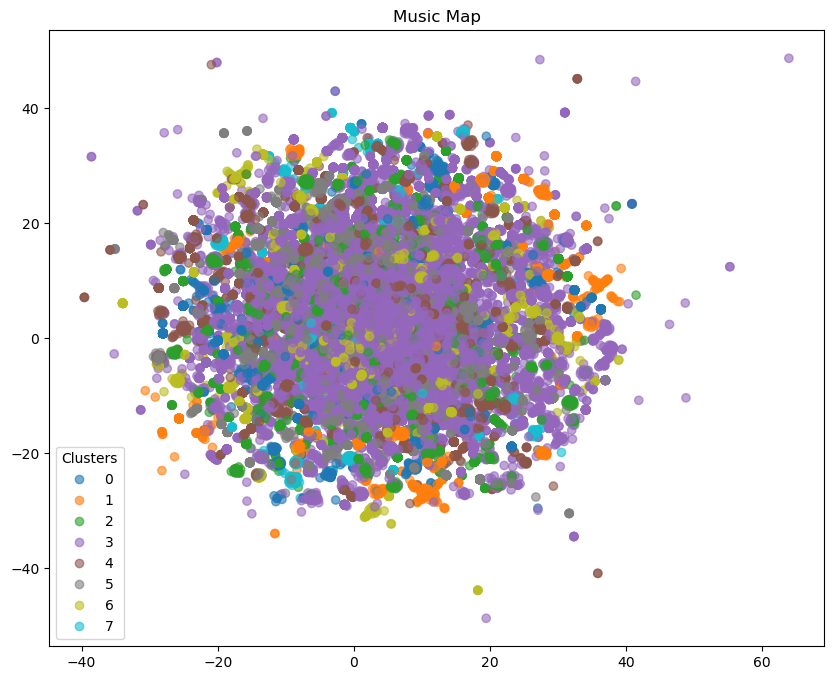

In [15]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=model_df["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("Music Map")
plt.show()